# Capítulo 10 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 10. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

Omega, rho = 7.292e-5, 1.2
f_lat = lambda phi: 2*Omega*np.sin(np.deg2rad(phi))

## T1 — Círculos inerciais

**Solução.** Com $\dot u = fv$, $\dot v = -fu$: $\ddot u = -f^2u$ — oscilador de frequência $|f|$. A velocidade tem módulo constante $V$ e gira; o raio segue de $V^2/R = |f|V$: $R = V/|f|$, período $2\pi/|f|$.

In [2]:
V = 10.0
for phi in [-23.5, -60.0]:
    f = abs(f_lat(phi))
    print(f'φ = {phi:5.1f}°: T = {2*np.pi/f/3600:5.1f} h | R = {V/f/1e3:5.0f} km')

φ = -23.5°: T =  30.0 h | R =   172 km
φ = -60.0°: T =  13.8 h | R =    79 km


## T2 — Geostrofia proibida no equador

**Solução.** $\vec U_g = (1/\rho f)\hat k\times\nabla P$ diverge quando $f \to 0$: não há equilíbrio geostrófico no equador. Lá a PGF é equilibrada por **aceleração** (escoamentos transientes) e pela força centrífuga de curvaturas (equilíbrio ciclostrófico), e gradientes de pressão são rapidamente destruídos por ondas de gravidade — por isso o campo de pressão tropical é tão liso e a 'régua na carta' não funciona nos trópicos.

## T3 — O teto de PGF das altas

In [3]:
V_, f_, R_, G_ = sp.symbols('V f R G', positive=True)
# alta (anticiclone): V²/R = -G + f V  →  V² - fRV + GR = 0
sols = sp.solve(sp.Eq(V_**2 - f_*R_*V_ + G_*R_, 0), V_)
display(sols)
disc = sp.discriminant(V_**2 - f_*R_*V_ + G_*R_, V_)
print('discriminante ≥ 0 ⇒ f²R² − 4GR ≥ 0 ⇒ G ≤ f²R/4  ✓')
print('PGF (G=|∇P|/ρ) tem teto: perto do centro (R→0) o teto vai a zero —')
print('altas são obrigadas a ser suaves e de vento fraco no centro.')

[-sqrt(R)*sqrt(-4*G + R*f**2)/2 + R*f/2, sqrt(R)*sqrt(-4*G + R*f**2)/2 + R*f/2]

discriminante ≥ 0 ⇒ f²R² − 4GR ≥ 0 ⇒ G ≤ f²R/4  ✓
PGF (G=|∇P|/ρ) tem teto: perto do centro (R→0) o teto vai a zero —
altas são obrigadas a ser suaves e de vento fraco no centro.


## T4 — Ângulo de cruzamento das isóbaras

**Solução.** Equilíbrio com atrito linear $-\vec U/\tau$: na direção do vento, a PGF projetada equilibra o atrito ($|U|/\tau$); na transversal, Coriolis equilibra o resto. A razão dá $\tan\alpha = 1/(|f|\tau)$.

In [4]:
f = abs(f_lat(-30))
for tau_h in [0.5, 3.0]:
    alpha = np.rad2deg(np.arctan(1/(f*tau_h*3600)))
    print(f'τ = {tau_h:3.1f} h → α = {alpha:4.0f}°')
print('Atrito forte (τ curto, terra rugosa): cruzamento grande (~45°);')
print('oceano liso: ~10–20°. Os valores observados na CL. ✓')

τ = 0.5 h → α =   83°
τ = 3.0 h → α =   52°
Atrito forte (τ curto, terra rugosa): cruzamento grande (~45°);
oceano liso: ~10–20°. Os valores observados na CL. ✓


## T5 — Verificação de Ekman e transporte

In [5]:
z_, d_, Ug_, K_, f_ = sp.symbols('z delta U_g K f', positive=True)
U = Ug_*(1 - sp.exp(-z_/d_)*sp.cos(z_/d_))
V = Ug_*sp.exp(-z_/d_)*sp.sin(z_/d_)
eq1 = sp.simplify(K_*sp.diff(U, z_, 2) + f_*V)
eq2 = sp.simplify(K_*sp.diff(V, z_, 2) - f_*(U - Ug_))
eq1s = sp.simplify(eq1.subs(d_, sp.sqrt(2*K_/f_)))
eq2s = sp.simplify(eq2.subs(d_, sp.sqrt(2*K_/f_)))
print('K U\'\' + f V   =', eq1s)
print('K V\'\' − f(U−Ug) =', eq2s, ' → espiral verificada ✓')

transp_V = sp.integrate(V.subs(d_, sp.sqrt(2*K_/f_)), (z_, 0, sp.oo))
transp_U = sp.integrate((U - Ug_).subs(d_, sp.sqrt(2*K_/f_)), (z_, 0, sp.oo))
print('∫V dz =', sp.simplify(transp_V), ' | ∫(U−Ug) dz =', sp.simplify(transp_U))
print('Transporte ageostrófico igual nas duas componentes → resultante a 45°;')
print('o transporte de massa líquido da camada aponta PARA a baixa pressão —')
print('é o bombeamento de Ekman que enche as baixas de ar ascendente.')

K U'' + f V   = 0
K V'' − f(U−Ug) = 0  → espiral verificada ✓


∫V dz = sqrt(2)*sqrt(K)*U_g/(2*sqrt(f))  | ∫(U−Ug) dz = -sqrt(2)*sqrt(K)*U_g/(2*sqrt(f))
Transporte ageostrófico igual nas duas componentes → resultante a 45°;
o transporte de massa líquido da camada aponta PARA a baixa pressão —
é o bombeamento de Ekman que enche as baixas de ar ascendente.


---
## N1 — Medindo os círculos inerciais

In [6]:
def inercial(t, y, f, Um=0.0):
    x, yy, u, v = y
    return [u + Um, v, f*v, -f*u]

f = f_lat(-30)
T_teo = 2*np.pi/abs(f)
sol = solve_ivp(inercial, [0, 3*T_teo], [0, 0, 10, 0], args=(f,),
                max_step=300, rtol=1e-10, dense_output=True)
t = np.linspace(0, 3*T_teo, 3000)
x, y = sol.sol(t)[0], sol.sol(t)[1]
# período: retorno de v ao máximo
u, v = sol.sol(t)[2], sol.sol(t)[3]
picos = t[1:-1][(u[1:-1] > u[:-2]) & (u[1:-1] > u[2:])]
R_med = (x.max() - x.min())/2
print(f'período: medido {np.mean(np.diff(picos))/3600:.2f} h | teoria {T_teo/3600:.2f} h')
print(f'raio   : medido {R_med/1e3:.0f} km | teoria {10/abs(f)/1e3:.0f} km ✓')
print('Com vento médio, o círculo vira cicloide: o centro-guia deriva com o')
print('vento enquanto a parcela orbita — exatamente o rastro das boias oceânicas.')

período: medido 23.92 h | teoria 23.93 h
raio   : medido 137 km | teoria 137 km ✓
Com vento médio, o círculo vira cicloide: o centro-guia deriva com o
vento enquanto a parcela orbita — exatamente o rastro das boias oceânicas.


## N2 — Baixa intensa: quão ageostrófica?

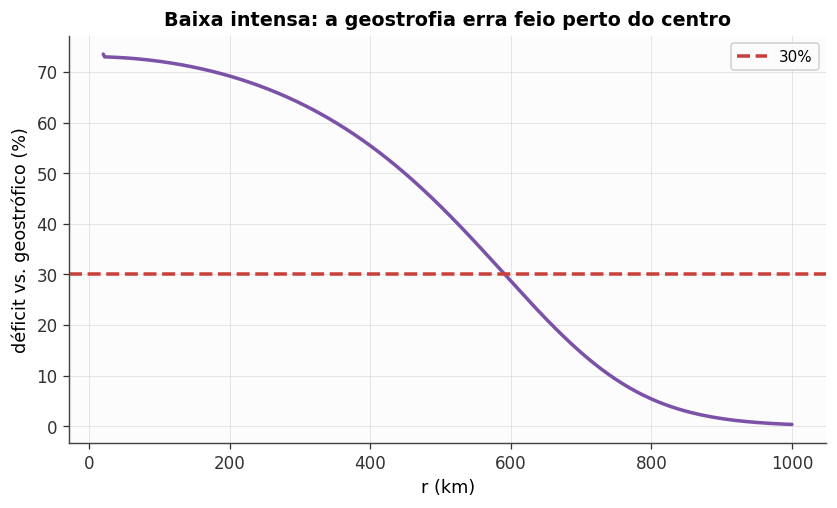

déficit máximo: 74% | erro > 30% para r < 592 km


In [7]:
f = abs(f_lat(-30))
r = np.linspace(20e3, 1000e3, 500)
dP, L = 40e2, 250e3
P_r = 101300 - dP*np.exp(-(r/L)**2/2)
PGF = np.gradient(P_r, r)/rho
Ug = PGF/f
Vg = (-f*r + np.sqrt((f*r)**2 + 4*r*PGF))/2
defc = 100*(1 - Vg/np.maximum(Ug, 1e-9))

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(r/1e3, defc, color=CORES['roxo'])
ax.axhline(30, color=CORES['vermelho'], ls='--', label='30%')
ax.set(xlabel='r (km)', ylabel='déficit vs. geostrófico (%)',
       title='Baixa intensa: a geostrofia erra feio perto do centro')
ax.legend()
plt.show()
print(f'déficit máximo: {np.nanmax(defc):.0f}% | '
      f'erro > 30% para r < {r[np.argmax(defc < 30)]/1e3:.0f} km')

## N3 — Ekman com $K(z)$ realista

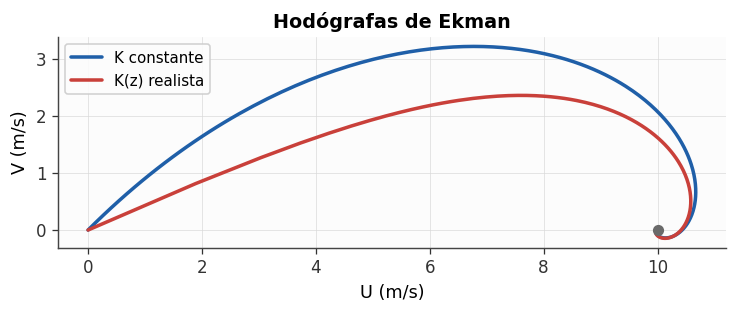

K pequeno junto ao chão gira MAIS o vento na superfície (ângulo maior)
e concentra a espiral embaixo — mais parecido com observações reais.


In [8]:
f = abs(f_lat(-30)); Ug0 = 10.0
n = 500
zg = np.linspace(0, 2500, n); dz = zg[1]-zg[0]
K0 = 5.0
Kz = np.maximum(0.2, K0*(zg/100.0)*np.exp(-zg/300.0))

def resolve(Kperfil):
    A = np.zeros((n, n), complex); b = np.zeros(n, complex)
    Km = 0.5*(Kperfil[1:] + Kperfil[:-1])          # K nas meias-camadas
    for i in range(1, n-1):
        A[i, i-1] = Km[i-1]/dz**2
        A[i, i]   = -(Km[i-1] + Km[i])/dz**2 - 1j*f
        A[i, i+1] = Km[i]/dz**2
        b[i] = -1j*f*Ug0
    A[0, 0] = 1.0; b[0] = 0.0
    A[-1, -1] = 1.0; b[-1] = Ug0
    return np.linalg.solve(A, b)

W_var = resolve(Kz)
W_cte = resolve(np.full(n, K0))

fig, ax = plt.subplots(figsize=(7.5, 5.6))
ax.plot(W_cte.real, W_cte.imag, color=CORES['azul'], label='K constante')
ax.plot(W_var.real, W_var.imag, color=CORES['vermelho'],
        label='K(z) realista')
ax.scatter([Ug0], [0], color=CORES['cinza'], zorder=5)
ax.set(xlabel='U (m/s)', ylabel='V (m/s)', title='Hodógrafas de Ekman')
ax.legend(); ax.set_aspect('equal')
plt.show()
print('K pequeno junto ao chão gira MAIS o vento na superfície (ângulo maior)')
print('e concentra a espiral embaixo — mais parecido com observações reais.')

## N4 — $w$ × ângulo de atrito

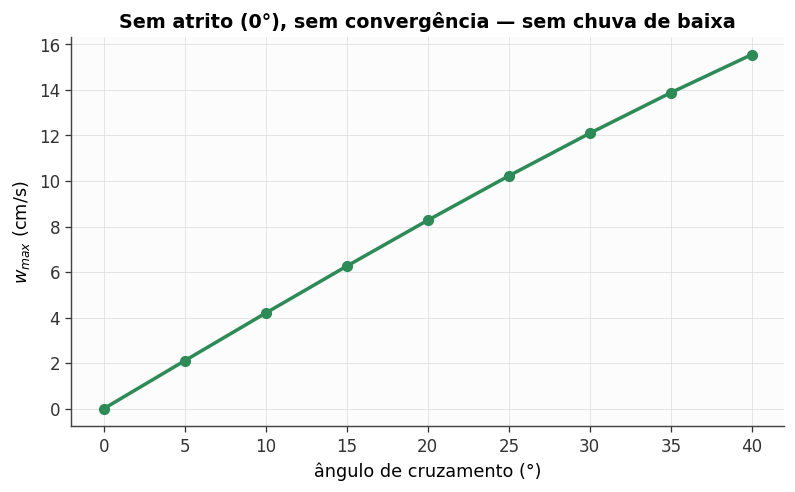

Em 0° o vento é paralelo às isóbaras: divergência nula (a menos de
curvatura fraca) — é o ATRITO que faz as baixas chovererem.


In [9]:
x = np.linspace(-1500e3, 1500e3, 150)
X, Y = np.meshgrid(x, x)
P = 101300 - 20e2*np.exp(-(X**2 + Y**2)/(2*(400e3)**2))
dPdx = np.gradient(P, x, axis=1); dPdy = np.gradient(P, x, axis=0)
f_s = f_lat(-30)
Ugx = -dPdy/(rho*f_s); Ugy = dPdx/(rho*f_s)

angulos = np.arange(0, 41, 5)
w_max = []
for a_deg in angulos:
    ang = np.deg2rad(a_deg)*np.sign(f_s)
    Ux = 0.85*(Ugx*np.cos(ang) - Ugy*np.sin(ang))
    Uy = 0.85*(Ugx*np.sin(ang) + Ugy*np.cos(ang))
    div = np.gradient(Ux, x, axis=1) + np.gradient(Uy, x, axis=0)
    w_max.append((-1000.0*div*100).max())

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(angulos, w_max, 'o-', color=CORES['verde'])
ax.set(xlabel='ângulo de cruzamento (°)', ylabel='$w_{max}$ (cm/s)',
       title='Sem atrito (0°), sem convergência — sem chuva de baixa')
plt.show()
print('Em 0° o vento é paralelo às isóbaras: divergência nula (a menos de')
print('curvatura fraca) — é o ATRITO que faz as baixas chovererem.')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*